# Cryosphere model Comparison tool (CmCt) --- Calving Research

### This notebooks has been used to research pasrts about the calving comparison tool, and is not intended for end users.

The input ice sheet model needs to be provided as a netCDF file. The user may upload a single input file that includes multiple years; future enhancements to this tool will allow users to upload model ensembles.

There are several requirements for the comparison:

### Rectangular grid

At time of writing, models *must* be defined on a rectangular X-Y grid in the ISMIP6 standard projected polar-stereographic space. (Note, NOT a lat-lon grid!) The ISMIP6 standard projection is defined [here](https://theghub.org/groups/ismip6/wiki). 

### Date range


The CmCt Calving tool compares user uploaded ice sheet model to satellite calving data, derived from the   satellite missions. The CmCt reprojects modeled ice sheet mass change into calving space and performs a direct quantitative comparison, calculating model-observation discrepancies, therefore bringing the ice sheet model and calving data to the same spatial resolution for comparison.

## Calving dataset description

## Input data requirements

In [28]:
## Import modules
import os,sys
import numpy as np
import geopandas as gpd
import cftime 
import gc
import shapely
import json 
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets
import matplotlib.pyplot as plt
# Add the directory containing 'cmct' to the Python path
# Navigate two levels up to reach main CmCt dir
cmct_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))

# Initialising Logger 
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


# Import utilities for this comparison
sys.path.insert(0,cmct_dir)
from cmct.time_utils import check_datarange
from cmct.calving import *
from cmct.calving_modules.interpolation import *
from cmct.calving_modules.json_to_netcdf import *
from cmct.shapefile_utils import *          

# Force initial garbage collection
gc.collect()


1831

In [29]:
# Reload modules to pick up any changes to imports
import importlib
import cmct.calving
import cmct.shapefile_utils
importlib.reload(cmct.shapefile_utils)
importlib.reload(cmct.calving)

# Re-import to ensure functions are available
from cmct.calving import *
from cmct.shapefile_utils import *

### Configuration

In [30]:
# Observation Dataset
# Ice sheet
loc = 'GIS' # 'GIS' or 'AIS'

# Set the observation data dir path
obs_filename = cmct_dir + '/data/calving/observed_icemask_ismip_annual.nc'

# To use aggregation functions for basin 
basin_aggregation = True # IMPORTANT

basin_shapes = cmct_dir + '/data/ne_10m_coastline/ne_10m_coastline.shp'

# Set the Model Data dir path
model_filename = cmct_dir + "/test/calving/ensemble/sftgif_B001_hist.nc"

# Set time range for comparison
start_year = 2007
end_year = 2010

# List of basins (ex [NW, NE]) to compare if all -> "all"
# If you do not know which basins are in the model, you can put "auto"
# NOTE: Align this list with the basins in the model.
basin_list = "all"

# Output filetype and filename
filetype = 'netcdf' # netcdf or json or None
filename = 'calving_comparison'

# Optional Configurations 
interpolation_method = 'slinear' # 'nearest', 'linear', 'cubic'
accuracy_calculation_method = 'mean' # 'mean', 'RMS',   

colors = {
    'CW': 'blue',
    'NE': 'red', 
    'SE': 'green',
    'SW': 'orange',
    'NO': 'purple',
    'NW': 'brown'
    }



# Error Checking

In [31]:
# Check if observation file exist
if not os.path.exists(obs_filename):
    raise FileNotFoundError(f"Observation file not found: {obs_filename}")

# # Check if model file exist
if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Model file not found: {model_filename}")


In [32]:
# TODO: add auto functionality
# if basin_list == "auto":
#     load_basins_exp(cmct_dir, "all")
# else:
#     basins = load_basins_exp(cmct_dir, basin_list)
basins = load_basins_exp(cmct_dir, basin_list)

## Set polar sterographic projection definition
Currently, the CmCt expects the model data to be provided in a specific polar stereographic projection. This is hardcoded in the notebook. As a future enhancement, the projection can be obtained from the loaded model.

In [33]:
# polar_stereographic = set_projection(loc)

## Process Observation Data

In [34]:
print(obs_filename)
gsfc = load_gsfc_calving(obs_filename, basins)
print(vars(gsfc))


/Users/aditya_pachpande/Documents/GitHub/CmCt/data/calving/observed_icemask_ismip_annual.nc
{'ds': <xarray.Dataset> Size: 2GB
Dimensions:   (x: 1680, y: 2880, year: 49)
Coordinates:
  * x         (x) float64 13kB -7.195e+05 -7.185e+05 ... 9.585e+05 9.595e+05
  * y         (y) float64 23kB -3.45e+06 -3.448e+06 ... -5.715e+05 -5.705e+05
  * year      (year) float64 392B 1.973e+03 1.974e+03 ... 2.02e+03 2.021e+03
Data variables:
    ice_mask  (year, y, x) float64 2GB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0}


## Process Model Data 

In [35]:
print(model_filename)
model_res = load_model_calving(model_filename)
print(vars(model_res)) 
  

/Users/aditya_pachpande/Documents/GitHub/CmCt/test/calving/ensemble/sftgif_B001_hist.nc
{'ds': <xarray.Dataset> Size: 271MB
Dimensions:              (x: 1681, y: 2881, time: 14)
Coordinates:
  * x                    (x) float64 13kB -7.2e+05 -7.19e+05 ... 9.6e+05
  * y                    (y) float64 23kB -3.45e+06 -3.449e+06 ... -5.7e+05
  * time                 (time) float64 112B 2.007e+03 2.008e+03 ... 2.02e+03
Data variables:
    Polar_Stereographic  |S1 1B ...
    ice_mask             (time, x, y) float32 271MB ...}


## Checking if time matches in both datasets

In [36]:
# Simplifying date data type
gsfc.ds["time"] = gsfc.time
model_res.ds["time"] = [dt for dt in model_res.time.values]

# Handelling Time Range
check_data_daterange(gsfc.time.values, model_res.time.values, start_year, end_year)


<class 'numpy.ndarray'> <class 'numpy.ndarray'> <class 'int'> <class 'int'>
The selected dates 2007 and 2010 are within the range of the model data. These are accepted.


# Interpolation

In [37]:
resampler = Resampling(model_res, target_data=gsfc, interpolation_method=interpolation_method)
resampled_data = resampler.resample()

# Update the gsfc object with the resampled data
model_res.ds = resampled_data

# Clean up resampler object and force garbage collection
del resampler
gc.collect()



TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

### If you want to you can download the interpolated data 
by default its commented out.

In [ ]:
# Save the resampled data to a new NetCDF file
# output_netcdf_filename = cmct_dir + '/notebooks/Calving/resampled_calving_obs_data.nc'
# resampled_data.to_netcdf(output_netcdf_filename, mode='w', format='NETCDF4')

# Comparison     

In [ ]:
all_datasets = []
analyses = []

for year in range(start_year, end_year + 1):
    logging.info(f"Processing year {year}")

    # Check if both datasets have data for the current year
    if gsfc is not None and model_res is not None:
        
        # Use the new direct Dataset creation function
        year_ds, analysis = find_calving_per_year_direct_ds(gsfc, model_res, year)
        
        all_datasets.append(year_ds)
        analyses.append(analysis)
        
        logging.info(f"Processed {analysis['VALID_POINTS']} valid points for year {year}")
        print(f"Comparison for {year}: {analysis['VALID_POINTS']} valid data points")
    
    else:
        logging.warning(f"No data available for {year} in one or both datasets")
        print(f"No data available for {year} in one or both datasets.")
        continue

logging.info(f"Completed processing. Total years with data: {len(all_datasets)}")

# Combine all yearly datasets into a single multi-year dataset
if all_datasets:
    gsfc_ds_residual = xr.concat(all_datasets, dim='year')
    
    # Clean up individual datasets list after concatenation
    del all_datasets
    gc.collect()
else:
    raise ValueError("No valid datasets created")

# Print summary statistics
for i, analysis in enumerate(analyses):
    year = start_year + i
    print(f"Year {year}: AVG={analysis['ABS_AVG_RESIDUAL']}, RMS={analysis['RMS_RESIDUAL']}, Valid Points={analysis['VALID_POINTS']}, Face Sum={analysis['SUM_RESIDUAL']}, ")

residuals = load_residuals(gsfc_ds_residual)

del analyses
gc.collect()

2025-07-08 14:26:08,403 - INFO - Processing year 2006
2025-07-08 14:26:08,423 - INFO - Starting direct Dataset creation for year 2006
2025-07-08 14:26:08,423 - INFO - Starting direct Dataset creation for year 2006
2025-07-08 14:26:08,692 - INFO - Processing 4838400 grid points...
2025-07-08 14:26:08,692 - INFO - Processing 4838400 grid points...
2025-07-08 14:26:09,110 - INFO - Found 4838400 valid points out of 4838400 total
2025-07-08 14:26:09,111 - INFO - Processed 4838400 valid points for year 2006
2025-07-08 14:26:09,111 - INFO - Processing year 2007
2025-07-08 14:26:09,111 - INFO - Starting direct Dataset creation for year 2007
2025-07-08 14:26:09,110 - INFO - Found 4838400 valid points out of 4838400 total
2025-07-08 14:26:09,111 - INFO - Processed 4838400 valid points for year 2006
2025-07-08 14:26:09,111 - INFO - Processing year 2007
2025-07-08 14:26:09,111 - INFO - Starting direct Dataset creation for year 2007
2025-07-08 14:26:09,264 - INFO - Processing 4838400 grid points...

Comparison for 2006: 4838400 valid data points


2025-07-08 14:26:09,365 - INFO - Found 4838400 valid points out of 4838400 total
2025-07-08 14:26:09,366 - INFO - Processed 4838400 valid points for year 2007
2025-07-08 14:26:09,366 - INFO - Processing year 2008
2025-07-08 14:26:09,366 - INFO - Starting direct Dataset creation for year 2008
2025-07-08 14:26:09,366 - INFO - Processed 4838400 valid points for year 2007
2025-07-08 14:26:09,366 - INFO - Processing year 2008
2025-07-08 14:26:09,366 - INFO - Starting direct Dataset creation for year 2008
2025-07-08 14:26:09,550 - INFO - Processing 4838400 grid points...
2025-07-08 14:26:09,550 - INFO - Processing 4838400 grid points...


Comparison for 2007: 4838400 valid data points


2025-07-08 14:26:09,673 - INFO - Found 4838400 valid points out of 4838400 total
2025-07-08 14:26:09,674 - INFO - Processed 4838400 valid points for year 2008
2025-07-08 14:26:09,674 - INFO - Processing year 2009
2025-07-08 14:26:09,674 - INFO - Starting direct Dataset creation for year 2009
2025-07-08 14:26:09,674 - INFO - Processed 4838400 valid points for year 2008
2025-07-08 14:26:09,674 - INFO - Processing year 2009
2025-07-08 14:26:09,674 - INFO - Starting direct Dataset creation for year 2009
2025-07-08 14:26:09,839 - INFO - Processing 4838400 grid points...
2025-07-08 14:26:09,839 - INFO - Processing 4838400 grid points...


...

2025-07-08 14:26:09,930 - INFO - Found 4838400 valid points out of 4838400 total
2025-07-08 14:26:09,930 - INFO - Processed 4838400 valid points for year 2009
2025-07-08 14:26:09,931 - INFO - Processing year 2010
2025-07-08 14:26:09,931 - INFO - Starting direct Dataset creation for year 2010
2025-07-08 14:26:09,930 - INFO - Processed 4838400 valid points for year 2009
2025-07-08 14:26:09,931 - INFO - Processing year 2010
2025-07-08 14:26:09,931 - INFO - Starting direct Dataset creation for year 2010
2025-07-08 14:26:10,117 - INFO - Processing 4838400 grid points...
2025-07-08 14:26:10,117 - INFO - Processing 4838400 grid points...


Comparison for 2009: 4838400 valid data points


2025-07-08 14:26:10,215 - INFO - Found 4838400 valid points out of 4838400 total
2025-07-08 14:26:10,215 - INFO - Processed 4838400 valid points for year 2010
2025-07-08 14:26:10,216 - INFO - Completed processing. Total years with data: 5
2025-07-08 14:26:10,215 - INFO - Processed 4838400 valid points for year 2010
2025-07-08 14:26:10,216 - INFO - Completed processing. Total years with data: 5


Comparison for 2010: 4838400 valid data points
Year 2006: AVG=0.025, RMS=0.132, Valid Points=4838400, Face Sum=50771.160868830426, 
Year 2007: AVG=0.025, RMS=0.132, Valid Points=4838400, Face Sum=50658.120868353944, 
Year 2008: AVG=0.025, RMS=0.132, Valid Points=4838400, Face Sum=50404.83086887143, 
Year 2009: AVG=0.025, RMS=0.132, Valid Points=4838400, Face Sum=50058.98086811177, 
Year 2010: AVG=0.025, RMS=0.132, Valid Points=4838400, Face Sum=49804.86086486686, 


0

# Plot Generation

## Configuration
- gsfc_ds_residual required for plot generation

In [ ]:
# Which year do you want plots for?
year = 2007

cmap = 'ocean' # Leave default to Ocean :)
aspect = 'auto'

# Plot config
plt.figure(figsize=(10, 6))
# plt.cm.viridis.set_bad('lightblue')  # Set color for NaN values

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

Data shape for year 2007: (2880, 1680)
Data range: -1.0 to 1.0
Testing plot function...


<Figure size 640x480 with 0 Axes>

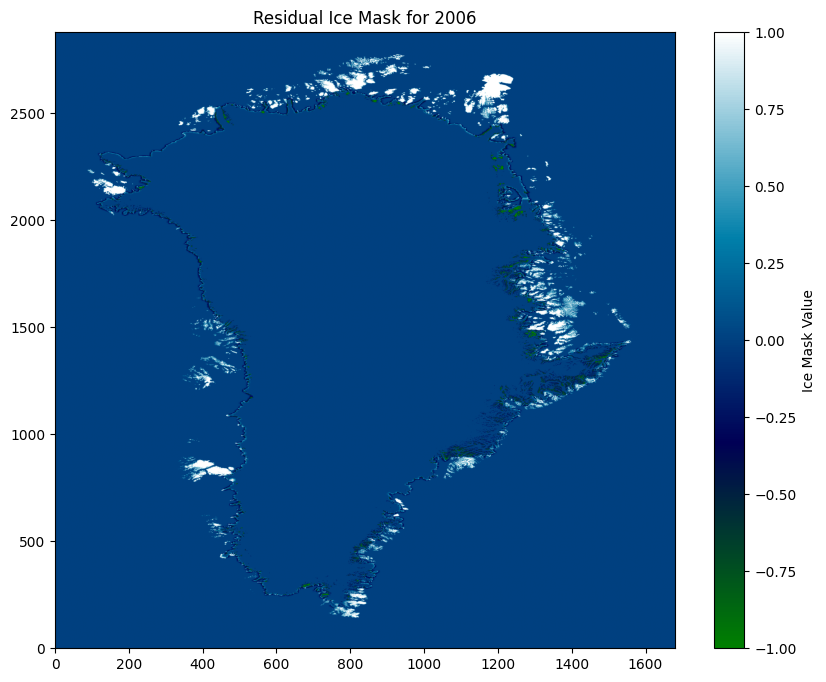

interactive(children=(FloatSlider(value=2006.0, description='Year:', max=2010.0, min=2006.0, step=1.0), Output…

<function __main__.plot_time_residuals(year)>

In [ ]:
data = residuals.ds.sel(year=year)
data = data.residual.values  # Extract the residual values for the specified year
print(f"Data shape for year {year}: {data.shape}")
print(f"Data range: {np.nanmin(data)} to {np.nanmax(data)}")

rotated_data = rotated_data_year(residuals, year)
# im = plt.imshow(rotated_data, cmap=cmap, origin='upper', aspect=aspect)

def plot_time_residuals(year):
    try:
        plt.clf()
        plt.figure(figsize=(10, 8))
        im = plt.imshow(rotated_data, cmap=cmap, origin='lower', aspect=aspect)

        plt.title(f"Residual Ice Mask for {year}")
        plt.colorbar(im, label='Ice Mask Value')
        
        plt.show()
        
        # Clean up plot objects
        plt.close('all')
        gc.collect()
        
    except Exception as e:
        print(f"Error plotting year {year}: {e}")
        print(f"Available years in dataset: {gsfc_ds_residual.year.values}")

print("Testing plot function...")
plot_time_residuals(start_year)

time_slider = FloatSlider(
    value=start_year, 
    min=start_year, 
    max=end_year, 
    step=1, 
    description='Year:', 
    continuous_update=True
)
interact(plot_time_residuals, year=time_slider)


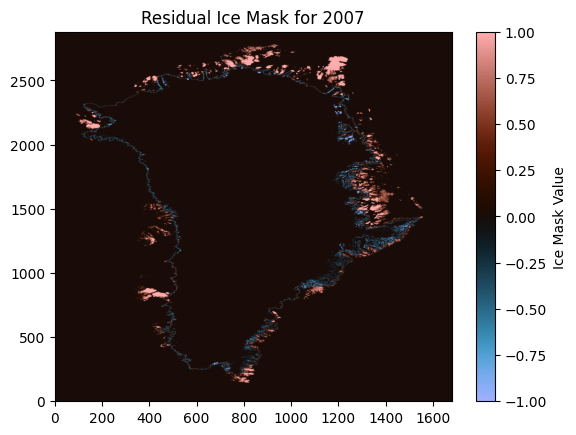

In [ ]:
# Plotting the residual for the specified year
rotated_data = np.rot90(data, k=0)

plt.imshow(rotated_data, cmap='berlin', origin='lower', aspect='auto')
plt.title(f"Residual Ice Mask for {year}")
plt.colorbar(label='Ice Mask Value')

# Aggregating based on Basin Shape

## Plotting and Fitting Shape File

In [ ]:
if not basin_aggregation:
    exit("Basin aggregation is not enabled. Please set basin_aggregation to True to proceed with basin-wise plotting.")

In [ ]:
from cmct.shapefile_utils import *
import gc

shape_file = (cmct_dir + '/data/calving/GRE_Basins_IMBIE2_v1.3.shp')

gdf_shape, new_gdf_shape, rotated_data_shape = fit_basins_per_year(residuals, basin_aggregation=True, shape_file=shape_file, year=year)
print("")
print(f"Shape File Shape: {gdf_shape}")
print(f"New Shape File Shape: {new_gdf_shape}")

# Clean up shape file variable
del shape_file
gc.collect()



Conversion complete. CRS: EPSG:3413
Number of interpolated points: 347100
Conversion complete. CRS: EPSG:3413
Number of interpolated points: 347100

Shape File Shape: [-618298.236964635, 836912.0293049013, -3300349.8060265062, -673506.0000000029]
New Shape File Shape: [87.0, 1559.9999999999998, 141.0, 2776.0]

Shape File Shape: [-618298.236964635, 836912.0293049013, -3300349.8060265062, -673506.0000000029]
New Shape File Shape: [87.0, 1559.9999999999998, 141.0, 2776.0]


0

## Recognizing Separate Basins

In [ ]:
basins = load_basins_exp(cmct_dir, basin_list)

# Clean up temporary variables
gc.collect()


0

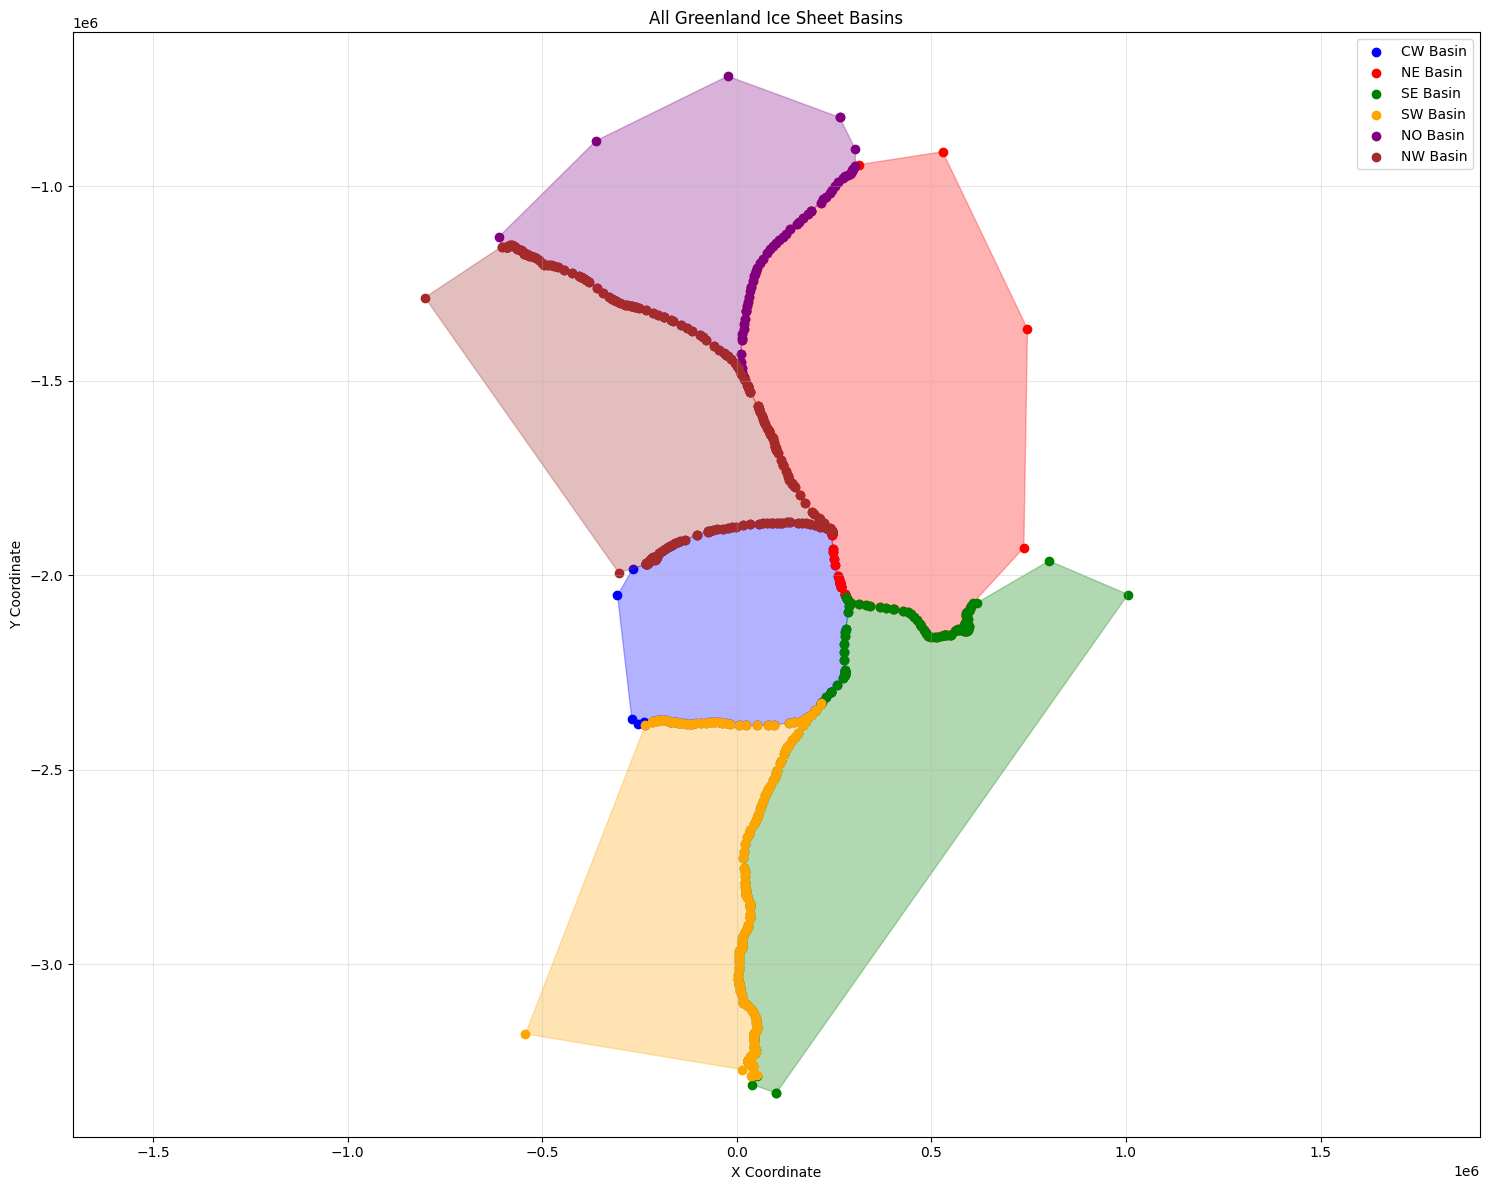

In [ ]:
# Plotting all the basins
plt.figure(figsize=(15, 12))

# Define colors for each basin

# Plot each basin
for basin_name, basin_data in basins.items():
    # Extract coordinates from the polygon
    if hasattr(basin_data, 'exterior'):
        # basin_data is a Polygon object
        x_coords, y_coords = basin_data.exterior.xy
    else:
        # basin_data is a dictionary with x, y coordinates
        x_coords = basin_data["x"]
        y_coords = basin_data["y"]
    
    plt.scatter(x_coords, y_coords, 
                linewidth=1, color=colors[basin_name],
                label=f'{basin_name} Basin')
    
    # Fill the basin polygon for better visualization
    plt.fill(x_coords, y_coords, color=colors[basin_name],
             alpha=0.3)

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('All Greenland Ice Sheet Basins')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')  # Equal aspect ratio
plt.tight_layout()
plt.show()

In [ ]:
from numba import jit
import numpy as np
from shapely.geometry import Point
import time
import gc

# Create basins_polygons dictionary from basins data
basins_polygons = {}
for basin_name, basin_data in basins.items():
    if hasattr(basin_data, 'exterior'):
        # basin_data is already a Polygon object
        basins_polygons[basin_name] = basin_data
    else:
        # basin_data is a dictionary with x, y coordinates - convert to Polygon
        x_coords = basin_data["x"]
        y_coords = basin_data["y"]
        coords = list(zip(x_coords, y_coords))
        basins_polygons[basin_name] = shapely.geometry.Polygon(coords)

# Converting basin polygons to numpy arrays
basin_names = list(basins_polygons.keys())
basin_polygons_arrays = []

for basin_name in basin_names:
    polygon = basins_polygons[basin_name]
    coords = list(polygon.exterior.coords)
    x_coords = np.array([coord[0] for coord in coords], dtype=np.float64)
    y_coords = np.array([coord[1] for coord in coords], dtype=np.float64)
    basin_polygons_arrays.append((x_coords, y_coords))
    
    del polygon, coords, x_coords, y_coords

if hasattr(gsfc_ds_residual, 'x') and hasattr(gsfc_ds_residual, 'y'):
    
    year_data = gsfc_ds_residual.sel(year=year)
    x_coords_1d = year_data.x.values
    y_coords_1d = year_data.y.values    
    
    # Creating coordinate meshgrid
    x_coords_2d, y_coords_2d = np.meshgrid(x_coords_1d, y_coords_1d, indexing='xy')
    x_flat = x_coords_2d.flatten().astype(np.float64)
    y_flat = y_coords_2d.flatten().astype(np.float64)
    
    del x_coords_2d, y_coords_2d, x_coords_1d, y_coords_1d
    
else:
    height, width = rotated_data.shape
    x_min, x_max, y_min, y_max = new_gdf_shape
    
    x_coords_1d = np.linspace(x_min, x_max, width)
    y_coords_1d = np.linspace(y_min, y_max, height)
    
    x_coords_2d, y_coords_2d = np.meshgrid(x_coords_1d, y_coords_1d, indexing='xy')
    x_flat = x_coords_2d.flatten().astype(np.float64)
    y_flat = y_coords_2d.flatten().astype(np.float64)
    
    del x_coords_2d, y_coords_2d, x_coords_1d, y_coords_1d

gc.collect()

# Basin Assignment
basin_assignments, processing_time = basin_assignment(
    x_flat, y_flat, basin_polygons_arrays, batch_size=100000
)

basin_points = {basin_name: [] for basin_name in basin_names}
basin_points['unassigned'] = []

data_flat = rotated_data.flatten()

valid_data_mask = ~np.isnan(data_flat)
valid_indices = np.where(valid_data_mask)[0]

logging.info(f"   Valid data points: {len(valid_indices):,}")

# Process only valid data points
for i in valid_indices:
    basin_idx = basin_assignments[i]
    x, y = x_flat[i], y_flat[i]
    data_value = data_flat[i]
    
    if basin_idx >= 0:
        basin_name = basin_names[basin_idx]
        basin_points[basin_name].append({
            'x': x,
            'y': y,
            'basin_id': basin_name,
            'data_value': data_value
        })
    else:
        basin_points['unassigned'].append({
            'x': x,
            'y': y,
            'basin_id': 'unassigned',
            'data_value': data_value
        })

del x_flat, y_flat, data_flat, basin_assignments, valid_data_mask, valid_indices
gc.collect()

# Summary of basin assignments
total_valid_points = sum(len(points) for points in basin_points.values())
total_assigned = sum(len(points) for basin_name, points in basin_points.items() if basin_name != 'unassigned')

logging.info(f"Successfully assigned: {total_assigned:,} ({total_assigned/total_valid_points*100:.1f}%)")

for basin_name, points in basin_points.items():
    count = len(points)
    percentage = (count / total_valid_points) * 100 if total_valid_points > 0 else 0
    logging.info(f"  {basin_name:>12}: {count:>8,} points ({percentage:>5.1f}%)")




2025-07-08 14:26:22,876 - INFO -    Valid data points: 4,838,400
2025-07-08 14:26:27,048 - INFO - Successfully assigned: 2,631,140 (54.4%)
2025-07-08 14:26:27,049 - INFO -             CW:  262,998 points (  5.4%)
2025-07-08 14:26:27,049 - INFO -             NE:  655,873 points ( 13.6%)
2025-07-08 14:26:27,050 - INFO -             SE:  570,701 points ( 11.8%)
2025-07-08 14:26:27,050 - INFO -             SW:  377,290 points (  7.8%)
2025-07-08 14:26:27,050 - INFO -             NO:  348,808 points (  7.2%)
2025-07-08 14:26:27,051 - INFO -             NW:  415,470 points (  8.6%)
2025-07-08 14:26:27,051 - INFO -     unassigned: 2,207,260 points ( 45.6%)
2025-07-08 14:26:27,048 - INFO - Successfully assigned: 2,631,140 (54.4%)
2025-07-08 14:26:27,049 - INFO -             CW:  262,998 points (  5.4%)
2025-07-08 14:26:27,049 - INFO -             NE:  655,873 points ( 13.6%)
2025-07-08 14:26:27,050 - INFO -             SE:  570,701 points ( 11.8%)
2025-07-08 14:26:27,050 - INFO -             S

# Aggregation to basins for all years 


In [ ]:
basin_dataset = aggregating_basins(residuals, basins_polygons, years=range(start_year, end_year + 1))
gc.collect()

Processing year 2006...
  Year 2006: 4,838,400 valid points, 2,631,140 assigned to basins
Processing year 2007...
  Year 2006: 4,838,400 valid points, 2,631,140 assigned to basins
Processing year 2007...
  Year 2007: 4,838,400 valid points, 2,631,140 assigned to basins
Processing year 2008...
  Year 2007: 4,838,400 valid points, 2,631,140 assigned to basins
Processing year 2008...
  Year 2008: 4,838,400 valid points, 2,631,140 assigned to basins
Processing year 2009...
  Year 2008: 4,838,400 valid points, 2,631,140 assigned to basins
Processing year 2009...
  Year 2009: 4,838,400 valid points, 2,631,140 assigned to basins
Processing year 2010...
  Year 2009: 4,838,400 valid points, 2,631,140 assigned to basins
Processing year 2010...
  Year 2010: 4,838,400 valid points, 2,631,140 assigned to basins
  Year 2010: 4,838,400 valid points, 2,631,140 assigned to basins


0

## Calculating Basin Statistics per Year 

In [ ]:
stats = calculate_basin_statistics(basin_dataset)
gc.collect()


print("Basin Statistics Summary:")
print("=" * 80)

for year in sorted(stats.keys()):
    print(f"\nYear {year}:")
    print(f"{'Basin':<12} {'Count':<8} {'Sum':<10} {'Mean':<10} {'Std':<10} {'Min':<10} {'Max':<10} {'RMS':<10} {'RSS':<10} {'Winsorized Mean':<10} {'Outlier Weighted Mean':<10}")
    print("-" * 80)
    
    for basin_name in ['CW', 'NE', 'SE', 'SW', 'NO', 'NW']:
        if basin_name in stats[year]:
            s = stats[year][basin_name]
            print(f"{basin_name:<12} {s['count']:<8} {s['sum']:<10.4f} {s['mean']:<10.4f} {s['std']:<10.4f} "
                  f"{s['min']:<10.4f} {s['max']:<10.4f} {s['rms']:<10.4f} {s['rss']:<10.4f} {s['winsorized_mean']:<10.4f} {s['outlier_weighted_mean']:<10.4f}")

    if 'unassigned' in stats[year]:
        s = stats[year]['unassigned']
        print(f"{'unassigned':<12} {s['count']:<8} {s['sum']:<10.4f} {s['mean']:<10.4f} {s['std']:<10.4f} "
              f"{s['min']:<10.4f} {s['max']:<10.4f} {s['rms']:<10.4f} {s['rss']:<10.4f} {s['winsorized_mean']:<10.4f} {s['outlier_weighted_mean']:<10.4f}")

Basin Statistics Summary:

Year 2006:
Basin        Count    Sum        Mean       Std        Min        Max        RMS        RSS        Winsorized Mean Outlier Weighted Mean
--------------------------------------------------------------------------------
CW           262998   802.9208   0.0031     0.0818     -1.0000    1.0000     0.0818     1761.6438  0.0000     0.1996    
NE           655873   13926.2412 0.0212     0.1918     -1.0000    1.0000     0.1930     24425.5879 0.0133     0.3576    
SE           570701   920.7739   0.0016     0.1629     -1.0000    1.0000     0.1629     15147.7207 -0.0044    0.1022    
SW           377290   2898.6919  0.0077     0.1267     -1.0000    1.0000     0.1269     6079.9546  0.0000     0.3213    
NO           348808   11003.8789 0.0315     0.1989     -1.0000    1.0000     0.2014     14143.6299 0.0143     0.5714    
NW           415470   2002.5458  0.0048     0.1177     -1.0000    1.0000     0.1178     5761.6230  0.0000     0.2871    
unassigned   22072

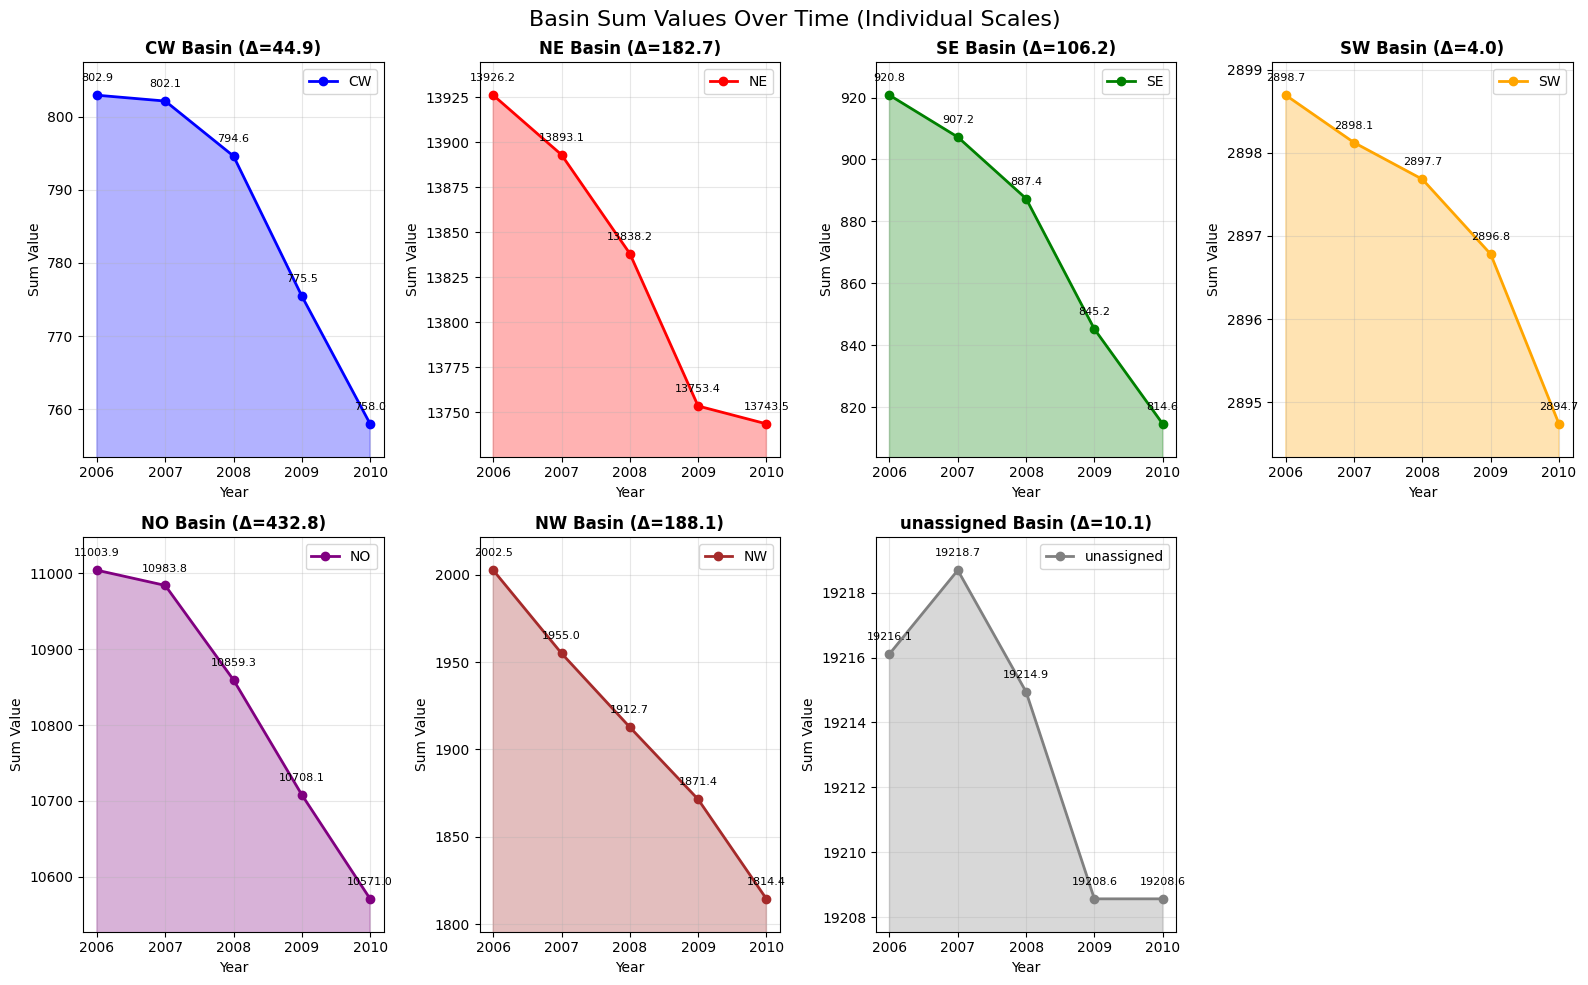

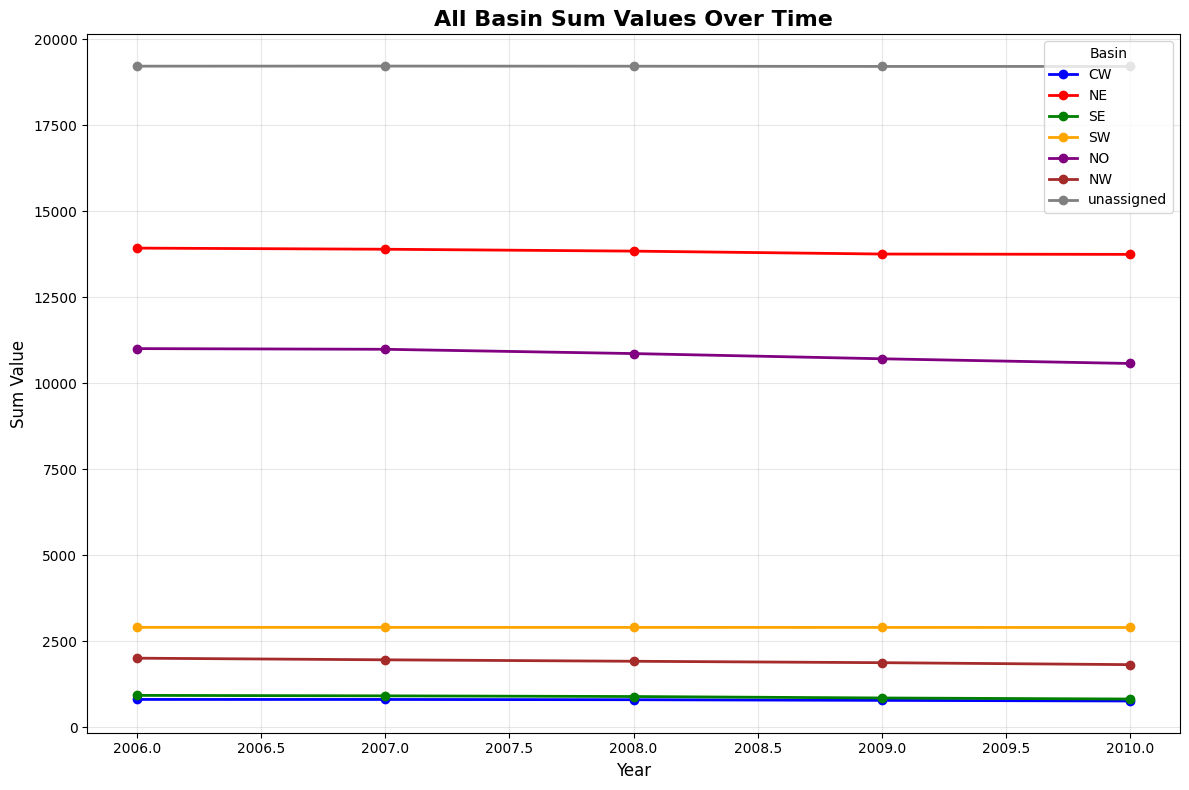


Summary Statistics for Basin Sums:
          CW: Min=758.0209, Max=802.9208, Mean=786.6289, Std= 17.3878, Delta= 44.9000
          NE: Min=13743.4922, Max=13926.2412, Mean=13830.8955, Std= 73.0174, Delta=182.7490
          SE: Min=814.5633, Max=920.7739, Mean=875.0298, Std= 39.5681, Delta=106.2106
          SW: Min=2894.7417, Max=2898.6919, Mean=2897.2039, Std=  1.3803, Delta=  3.9502
          NO: Min=10571.0400, Max=11003.8789, Mean=10825.2441, Std=165.2655, Delta=432.8389
          NW: Min=1814.4458, Max=2002.5458, Mean=1911.2197, Std= 65.1271, Delta=188.1000
  unassigned: Min=19208.5625, Max=19218.6934, Mean=19213.3750, Std=  4.1125, Delta= 10.1309


5076

In [ ]:
make_time_residual_plots(stats, colors, basin_list)


# Dataset Output Configuration [IN PROGRESS]

In [ ]:
# from cmct.calving_modules.json_to_netcdf import json_to_netcdf
# # If you would like to get an output file, set it up in the configuration code.
# if filetype == 'json':
#     output_filename = cmct_dir + f'/notebooks/Calving/{filename}.json'
#     json.dump(residuals_list, open(cmct_dir + '/notebooks/Calving/residuals.json', 'w'))
# elif filetype == 'netcdf':
#     output_filename = cmct_dir + f'/notebooks/Calving/{filename}.nc'
    
#     # GSFC Residual is a version of gsfc with the residuals
#     gsfc_ds_residual = json_to_netcdf(residuals_list)
#     gsfc_ds_residual.to_netcdf(output_filename, mode='w', format='NETCDF4')
#     logging.info(f"Saved NetCDF file to {output_filename}")
#     print(f"Dataset saved to: {output_filename}")
# else:
#     logging.info("Dataset created in memory, ready for plotting")
#     print("Dataset created in memory and ready for use")

# print(f"Dataset shape: {gsfc_ds_residual.dims}")
# print(f"Available variables: {list(gsfc_ds_residual.data_vars.keys())}")
# print(f"Coordinate dimensions: {list(gsfc_ds_residual.coords.keys())}") 